Preprocessing for Association Rules - Artist Co-occurrence

We want to find which artists show up together in the same genres ("fans also like"). Each genre is a basket, artists in that genre are the items. This notebook just cleans the data and builds those baskets.

In [25]:
!pip install kagglehub -q

import numpy as np
import pandas as pd
import os
import ast

Load the dataset

In [26]:
import kagglehub as kh

path = kh.dataset_download("serkantysz/550k-spotify-songs-audio-lyrics-and-genres")
print("Path to dataset files:", path)

dfA = pd.read_csv(os.path.join(path, 'artists.csv'))
print("Artists:", dfA.shape)

Path to dataset files: C:\Users\nhatt\.cache\kagglehub\datasets\serkantysz\550k-spotify-songs-audio-lyrics-and-genres\versions\1
Artists: (71440, 6)


Study the data

In [27]:
print(dfA.dtypes)
display(dfA.head())

id              str
name            str
followers     int64
popularity    int64
genres          str
main_genre      str
dtype: object


,id,name,followers,popularity,genres,main_genre
0,6YROFUbu5zRCHi2xkir5pk,Brian Hyland,67223,47,[],Pop
1,5tFRohaO5yEsuJxmMnlCO9,Barns Courtney,602647,62,[],Electronic
2,3w1Q754jb31h5CXQCcnLNL,Capcom Sound Team,210392,58,"['japanese vgm', 'soundtrack']",Electronic
3,3oDbviiivRWhXwIE8hxkVV,The Beach Boys,5139194,76,['baroque pop'],Classical
4,60zvRmhQHRxokEB1taAVpN,Beth Malone,1569,29,['musicals'],Classical


Missing value analysis

In [28]:
missing = dfA.isnull().sum()
percent_missing = (missing / len(dfA)) * 100
report = pd.DataFrame({'Missing Count': missing, 'Percent Missing': percent_missing})
report = report[report['Missing Count'] > 0].sort_values('Percent Missing', ascending=False)
display(report)

,Missing Count,Percent Missing
name,2,0.0028


Look at the genres column since thats what we need for the baskets

In [29]:
display(dfA['genres'].head(10))
print("example:", dfA['genres'].dropna().iloc[0])
print("nulls:", dfA['genres'].isna().sum())

0                                          []
1                                          []
2              ['japanese vgm', 'soundtrack']
3                             ['baroque pop']
4                                ['musicals']
5                   ['groove metal', 'metal']
6                                          []
7                                          []
8                        ["children's music"]
9    ['folk punk', 'anti-folk', 'indie folk']
Name: genres, dtype: str

example: []
nulls: 0


Data cleaning - drop artists with no genre info since they cant go in any basket

In [30]:
print("before:", len(dfA))

dfA_clean = dfA.dropna(subset=['genres']).copy()
dfA_clean = dfA_clean[~dfA_clean['genres'].str.strip().isin(['', '[]'])]

print("after: ", len(dfA_clean))
print("removed:", len(dfA) - len(dfA_clean))

before: 71440
after:  51860
removed: 19580


Parse the genres column - its stored as a string like "['pop', 'rock']" but we need it as an actual python list

In [31]:
def parse_list_col(x):
    if pd.isna(x) or str(x).strip() in ('', '[]', 'nan'):
        return []
    try:
        result = ast.literal_eval(str(x))
        if isinstance(result, list):
            return [str(item).strip() for item in result if str(item).strip()]
        return [str(result).strip()]
    except (ValueError, SyntaxError):
        return [item.strip() for item in str(x).split(',') if item.strip()]

In [32]:
dfA_clean['genres_list'] = dfA_clean['genres'].apply(parse_list_col)

display(dfA_clean[['name', 'genres_list']].head(10))

,name,genres_list
2,Capcom Sound Team,"[japanese vgm, soundtrack]"
3,The Beach Boys,[baroque pop]
4,Beth Malone,[musicals]
5,HELLYEAH,"[groove metal, metal]"
8,Sesame Street,[children's music]
9,The Mountain Goats,"[folk punk, anti-folk, indie folk]"
10,Cookie Monster,[children's music]
11,Clorofila,"[mexican indie, latin alternative, electrocumbia]"
12,Ram-Zet,"[avant-garde, progressive metal, gothic metal,..."
14,Catherine Zeta-Jones,[musicals]


In [33]:
# drop any that ended up with empty lists after parsing
print("before:", len(dfA_clean))
dfA_clean = dfA_clean[dfA_clean['genres_list'].apply(len) > 0].copy()
print("after: ", len(dfA_clean))

before: 51860
after:  51860


Quick look at what genres we have

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

all_genres = [g for genres in dfA_clean['genres_list'] for g in genres]
genre_series = pd.Series(all_genres)

print("total genre mentions:", len(all_genres))
print("unique genres:", genre_series.nunique())
display(genre_series.value_counts().head(20))

total genre mentions: 115522
unique genres: 754


musicals              1839
metalcore              950
trance                 942
reggae                 878
blues                  852
death metal            826
hardcore               819
jazz                   782
black metal            759
post-hardcore          725
darkwave               722
progressive trance     693
industrial             682
hardstyle              680
drum and bass          675
americana              666
hardcore punk          665
punk                   652
ebm                    650
dancehall              647
Name: count, dtype: int64

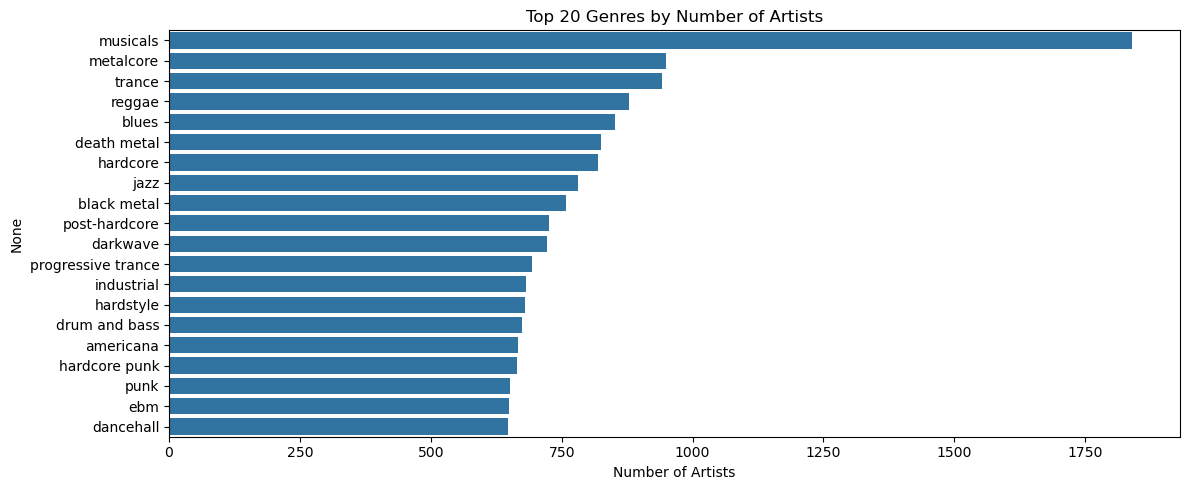

In [35]:
top_genres = genre_series.value_counts().head(20)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top 20 Genres by Number of Artists')
plt.xlabel('Number of Artists')
plt.tight_layout()
plt.show()

Build the baskets - explode genres so each row is one (artist, genre) pair then group by genre to get the list of artists in each genre

In [36]:
dfA_exploded = dfA_clean[['name', 'genres_list']].explode('genres_list')
dfA_exploded.columns = ['artist', 'genre']
dfA_exploded = dfA_exploded.dropna(subset=['genre'])

print(dfA_exploded.shape)
display(dfA_exploded.head(10))

(115522, 2)


,artist,genre
2,Capcom Sound Team,japanese vgm
2,Capcom Sound Team,soundtrack
3,The Beach Boys,baroque pop
4,Beth Malone,musicals
5,HELLYEAH,groove metal
5,HELLYEAH,metal
8,Sesame Street,children's music
9,The Mountain Goats,folk punk
9,The Mountain Goats,anti-folk
9,The Mountain Goats,indie folk


In [37]:
transactions = (
    dfA_exploded
    .groupby('genre')['artist']
    .apply(lambda x: list(set(x)))
    .reset_index()
)
transactions.columns = ['genre', 'artists']
transactions['basket_size'] = transactions['artists'].apply(len)

print("total baskets:", len(transactions))
display(transactions.head(10))

total baskets: 754


,genre,artists,basket_size
0,3 step,"[Enoo Napa, DJ Maphorisa, Black Motion, Da Cap...",41
1,acid house,"[Adonis, Mr. Fingers, Rebel MC, Tyree Cooper, ...",155
2,acid jazz,"[Buscemi, Shake Some Action!, Charles Earland,...",266
3,acid rock,"[The Electric Flag, Gnidrolog, Earthless, Eter...",242
4,acid techno,"[DJ Shredda, Hadone, Juliet Fox, Under Black H...",108
5,acoustic country,"[The Road Hammers, Jason Michael Carroll, Mark...",60
6,acoustic pop,"[Humming House, ROAM, Denis Kalytovskyi, Aslyn...",164
7,adult standards,"[Jack Jones, Astrud Gilberto, Neil Sedaka, Jul...",69
8,afrikaans pop,"[Ashton Nyte, Ruhan Du Toit, Robbie, Brendan P...",6
9,afro adura,"[Lil Kesh, Martinsfeelz, Spyro, Young Jonn, Yu...",47


In [38]:
print(transactions['basket_size'].describe())

count     754.000000
mean      152.623342
std       182.295147
min         1.000000
25%        23.000000
50%        86.000000
75%       224.750000
max      1826.000000
Name: basket_size, dtype: float64


Filter basket sizes - remove single-artist baskets (cant form pairs) and cap very large ones using IQR since super generic genres add noise

In [39]:
def check_outliers(x, factor=1.5):
    q25 = x.quantile(0.25)
    q75 = x.quantile(0.75)
    IQR = q75 - q25
    return q25 - IQR * factor, q75 + IQR * factor

_, upper_cap = check_outliers(transactions['basket_size'], factor=3)
print(f"upper cap (IQR factor=3): {upper_cap:.0f}")

transactions = transactions[
    (transactions['basket_size'] >= 2) &
    (transactions['basket_size'] <= upper_cap)
].copy()

print("baskets after filtering:", len(transactions))

upper cap (IQR factor=3): 830
baskets after filtering: 730


Save the cleaned transactions for the association rules notebook

In [40]:
os.makedirs('outputs', exist_ok=True)
transactions.to_csv('outputs/transactions.csv', index=False)

print("saved to outputs/transactions.csv")
print("baskets:", len(transactions))
all_items = [a for basket in transactions['artists'] for a in basket]
print("unique artists:", len(set(all_items)))

saved to outputs/transactions.csv
baskets: 730
unique artists: 48855
